## Inicialización del entorno

### Configurar y montar Google Drive

In [1]:
import sys
import os

# Directorio actual donde se está ejecutando el notebook
ruta_base = os.getcwd()

ruta_padre = os.path.abspath(os.path.join(ruta_base, '..'))

if ruta_padre not in sys.path:
    sys.path.append(ruta_padre)

print(f"Directorio de trabajo: {ruta_base}")
print(f"Directorio padre (añadido al path): {ruta_padre}")

Directorio de trabajo: c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning
Directorio padre (añadido al path): c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1


### Importación de librerías

In [2]:
#pip install -U pymgrid
#pip install optuna
#pip install seaborn

In [3]:
import pandas as pd
import numpy as np
from pymgrid import Microgrid
from pymgrid.modules import GridModule, BatteryModule, LoadModule, RenewableModule
import random
from collections import defaultdict

from custom_env_tabular import CustomEnvTabular

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import os
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


### Carga y preparación de datos

In [4]:
# PRECIOS DE LA RED (Península 2025)
ruta_precios = os.path.join(ruta_padre, 'data', 'external', 'precio2025-peninsula.csv')
df_precios = pd.read_csv(ruta_precios, sep=';')
df_precios['datetime'] = pd.to_datetime(df_precios['datetime'], utc=True)
df_precios = df_precios.sort_values('datetime').reset_index(drop=True)
# Convertir de €/MWh a €/kWh
precios_kwh = df_precios['value'].values / 1000.0

# DEMANDA (LOAD) Y GENERACIÓN SOLAR (PV)
ruta_load = os.path.join(ruta_padre, 'data', 'raw', 'load', 'RefBldgFullServiceRestaurantNew2004_v1.3_7.1_6A_USA_MN_MINNEAPOLIS.csv')
ruta_pv = os.path.join(ruta_padre, 'data', 'processed', 'pv_generacion_corregida_kw.csv')

df_load = pd.read_csv(ruta_load)
df_pv = pd.read_csv(ruta_pv)

load_series = df_load.iloc[:, -1].values
pv_series = df_pv.iloc[:, -1].values

# Asegurarnos de que todas las series tienen la misma longitud
min_len = min(len(precios_kwh), len(load_series), len(pv_series), 8760)
precios_kwh = precios_kwh[:min_len]
load_series = load_series[:min_len]
pv_series = pv_series[:min_len]

print(f"Datos cargados correctamente. Longitud de las series: {min_len} horas.")

Datos cargados correctamente. Longitud de las series: 8760 horas.


### Creación de los módulos de pymgrid

In [5]:
# RED ELÉCTRICA (GridModule)
# En las versiones recientes de pymgrid, los datos de la red se pasan como un DataFrame
grid_ts = pd.DataFrame({
    'import_price': precios_kwh,
    'export_price': precios_kwh * 0.5,
    'co2_per_kwh': 0.0                 # Rellenamos con 0, pero pymgrid necesita esta columna
})

grid = GridModule(
    max_import=200.0,
    max_export=200.0,
    time_series=grid_ts
)

# BATERÍA (BatteryModule)
battery = BatteryModule(
    min_capacity=10.0,
    max_capacity=200.0,
    max_charge=50.0,
    max_discharge=50.0,
    efficiency=0.9,
    init_soc=0.5
)

# DEMANDA Y PLACAS SOLARES
# Les pasamos directamente los arrays con los kW de cada hora
load = LoadModule(time_series=load_series)
pv = RenewableModule(time_series=pv_series)

### Ensamblaje de la microrred y el entorno gymnasium

In [6]:
modules = [
    ('grid', grid),
    ('battery', battery),
    ('load', load),
    ('pv', pv)
]

# Construimos la microrred
microrred = Microgrid(modules)

env = CustomEnvTabular(
    pymgrid_network=microrred,
    horizon=min_len,
    low_soc_threshold=0.20,   # Penalizar por debajo del 20%
    low_soc_penalty=50.0      # Penalización máxima (mayor que el beneficio de vender energía)
)

JUSTIFICACIÓN DE LA PENALIZACIÓN DE SoC (low_soc_penalty = 50.0):
Para evitar que el agente vacíe la batería ignorando el límite del 20%, la penalización debe ser mayor que el máximo beneficio económico posible en un paso.

Cálculos del peor caso:
 - Descarga máxima de batería: 50 kW
 - Precio máximo estimado de la red: ~0.25 €/kWh
 - Beneficio máximo por vender esa energía: 50 kW * 0.25 €/kWh = +12.5 €
 
Al fijar una penalización de 50.0 (aplicada proporcionalmente), garantizamos que vaciar la batería por debajo del umbral siempre resulte en una gran pérdida económica, obligando al agente a respetar el límite de seguridad.

### Prueba de funcionamiento

In [7]:
obs, info = env.reset()
print("¡Entorno inicializado con éxito, sin errores!")
print(f"Estado Inicial Discretizado [Carga_Neta, Batería_SoC, Precio, Hora]: {obs}")
print(f"Precio extraído para la primera hora: {info['current_import_price']:.4f} €/kWh")

¡Entorno inicializado con éxito, sin errores!
Estado Inicial Discretizado [Carga_Neta, Batería_SoC, Precio, Hora]: [2 5 3 0]
Precio extraído para la primera hora: 0.1832 €/kWh


# Funciones auxiliares

In [8]:
# 1. FUNCIÓN DE MUESTREO DE HIPERPARÁMETROS
def sample_q_params(trial):
    """Muestrea los hiperparámetros para Q-Learning Tabular."""
    return {
        "alpha": trial.suggest_float("alpha", 0.01, 0.3, log=True),
        "gamma": trial.suggest_float("gamma", 0.90, 0.999),
        "epsilon_decay_step": trial.suggest_float("epsilon_decay_step", 0.9998, 0.99998),
        "epsilon_min": 0.05
    }

In [9]:
# 2. FUNCIÓN DE EVALUACIÓN PURA (Sin exploración)
def evaluate_agent(env, Q, eval_episodes=1):
    """Evalúa la Q-Table actual (pura explotación) y devuelve el coste medio."""
    total_eval_cost = 0
    for _ in range(eval_episodes):
        obs, info = env.reset()
        state = tuple(obs)
        done = False
        ep_cost = 0

        while not done:
            # 1. Elegir la acción (ya sea por Q-Table o al azar si es desconocido)
            if state in Q:
                q_values = Q[state] # Ahora esto es una matriz 2D (9x3)
                
                # Encuentra el valor máximo en toda la matriz
                max_val = np.max(q_values)
                
                # np.argwhere devuelve una lista de coordenadas [bat, grid] de los máximos
                best_actions = np.argwhere(q_values == max_val)
                
                # Elegimos un par [bat, grid] al azar de entre los empatados
                idx = np.random.choice(len(best_actions))
                action = best_actions[idx] 
            else:
                # Si el estado es nuevo, sample() ya devuelve un array [bat, grid]
                action = env.action_space.sample()

            # 2. Ejecutar la acción en el entorno
            next_obs, reward, terminated, truncated, info = env.step(action)
            state = tuple(next_obs)
            done = terminated or truncated
            ep_cost += info.get('cost', 0)

        total_eval_cost += ep_cost

    return total_eval_cost / eval_episodes

In [10]:
GLOBAL_BEST_DIR = os.path.join(ruta_base, "Q-learning")
os.makedirs(GLOBAL_BEST_DIR, exist_ok=True)
GLOBAL_BEST_PATH = os.path.join(GLOBAL_BEST_DIR, "best_q_table_v1.pkl")
db_file_path = os.path.join(GLOBAL_BEST_DIR, "optuna_obj1.db")
DB_PATH = f"sqlite:///{db_file_path.replace(os.sep, '/')}"

# Empezamos el récord en limpio (infinito) porque es un experimento nuevo
global_best_cost = float('inf')

# Cargar el récord de este estudio concreto (por si lo pausas y lo reanudas mañana)
ESTUDIO_ACTUAL = "qlearning_obj1_bat_grid_v1"

try:
    study_obj1 = optuna.load_study(study_name=ESTUDIO_ACTUAL, storage=DB_PATH)
    if study_obj1.best_value < global_best_cost:
        global_best_cost = study_obj1.best_value
    print(f"Reanudando estudio {ESTUDIO_ACTUAL}. Mejor coste actual: {global_best_cost:.2f} €")
except Exception:
    print(f"Iniciando estudio {ESTUDIO_ACTUAL} desde cero en una nueva base de datos.")

Iniciando estudio qlearning_obj1_bat_grid_v1 desde cero en una nueva base de datos.


In [11]:
# 3. FUNCIÓN OBJECTIVE CON PRUNING Y TRACKER GLOBAL
def objective(trial: optuna.Trial) -> float:
    global global_best_cost

    # Instanciar entornos limpios para este trial
    microrred = Microgrid([('grid', grid), ('battery', battery), ('load', load), ('pv', pv)])
    env = CustomEnvTabular(
        pymgrid_network=microrred,
        horizon=min_len,
        low_soc_penalty=50.0,
        low_soc_threshold=0.20
    )
    
    microrred_eval = Microgrid([('grid', grid), ('battery', battery), ('load', load), ('pv', pv)])
    eval_env = CustomEnvTabular(
        pymgrid_network=microrred_eval,
        horizon=min_len,
        low_soc_penalty=50.0,
        low_soc_threshold=0.20
    )
    
    # 1. Obtener hiperparámetros
    params = sample_q_params(trial)
    alpha = params["alpha"]
    gamma = params["gamma"]
    epsilon_decay_step = params["epsilon_decay_step"]
    epsilon_min = params["epsilon_min"]

    # 2. Inicializar Q-Table y variables
    Q = defaultdict(lambda: np.zeros((9, 3)))
    epsilon = 1.0
    n_episodes = 50
    eval_freq = 2  # Evaluar y reportar a Optuna cada 2 episodios

    # 3. Bucle de Entrenamiento
    for ep in range(n_episodes):
        obs, info = env.reset()
        state = tuple(obs)
        done = False

        while not done:
            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()
            else:
                # Explotación: elegir mejor acción
                if state in Q:
                    q_values = Q[state]
                    best_actions = np.argwhere(q_values == np.max(q_values))
                    idx = np.random.choice(len(best_actions))
                    action = best_actions[idx]
                else:
                    action = env.action_space.sample()

            # ejecutar acción
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = tuple(next_obs)
            done = terminated or truncated

            # Actualizar Q-Table
            act_tuple = tuple(action) 
            max_next_q = np.max(Q[next_state]) # Valor máximo futuro
            
            Q[state][act_tuple] += alpha * (reward + gamma * max_next_q - Q[state][act_tuple])
            
            state = next_state

            epsilon = max(epsilon_min, epsilon * epsilon_decay_step)

        # -------------------------------------------------------------------
        # REPORTE A OPTUNA Y PRUNING (EVAL_CALLBACK manual)
        # -------------------------------------------------------------------
        if (ep + 1) % eval_freq == 0:
            current_cost = evaluate_agent(eval_env, Q)

            # Reportar a Optuna el coste actual en este paso intermedio
            trial.report(current_cost, ep)

            # Comprobar si debemos cortar este trial (Pruning)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

            # Comprobar si es el mejor modelo global histórico
            if current_cost < global_best_cost:
                global_best_cost = current_cost
                # Guardar la Q-Table como un diccionario normal para que pickle no falle
                with open(GLOBAL_BEST_PATH, 'wb') as f:
                    pickle.dump(dict(Q), f)
                print(f"NUEVO GLOBAL BEST: {current_cost:.2f} € → guardado en {GLOBAL_BEST_PATH}")

    # Devolver el coste final del agente entrenado
    return evaluate_agent(eval_env, Q)

# Búsqueda de mejores hiperparámetros

In [12]:
sampler = TPESampler(n_startup_trials=20)
pruner = MedianPruner(n_startup_trials=20, n_warmup_steps=5)

study = optuna.create_study(
    study_name=ESTUDIO_ACTUAL,
    storage=DB_PATH,
    direction="minimize",
    sampler=sampler,
    pruner=pruner,
    load_if_exists=True
)

try:
    study.optimize(objective, n_trials=100, n_jobs=1)
except KeyboardInterrupt:
    print("Búsqueda interrumpida manualmente.")

print("\nNumber of finished trials: ", len(study.trials))

# Pequeña validación por si lo paramos antes de que acabe un trial válido
if len(study.trials) > 0:
    try:
        best_trial = study.best_trial
        print(f"Best trial:\n  Coste Medio: {best_trial.value:.2f} €")
        print("  Params: ")
        for key, value in best_trial.params.items():
            print(f"    {key}: {value}")
    except ValueError:
        print("Aún no hay ningún trial completado con éxito para mostrar el mejor.")

[I 2026-03-26 09:31:46,101] A new study created in RDB with name: qlearning_obj1_bat_grid_v1


NUEVO GLOBAL BEST: 7749047.92 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning\Q-learning\best_q_table_v1.pkl
NUEVO GLOBAL BEST: 6364118.65 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning\Q-learning\best_q_table_v1.pkl
NUEVO GLOBAL BEST: 3626515.03 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning\Q-learning\best_q_table_v1.pkl
NUEVO GLOBAL BEST: 2918259.76 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning\Q-learning\best_q_table_v1.pkl
NUEVO GLOBAL BEST: 2533646.65 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning\Q-learning\best_q_table_v1.pkl
NUEVO GLOBAL BEST: 2337050.87 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning\Q-learning\best_q_table_v1.pkl
NUEVO GLOBAL BEST: 2327754.11 € → guardado en 

[I 2026-03-26 09:43:48,697] Trial 0 finished with value: 2326180.5000493205 and parameters: {'alpha': 0.06908813843912198, 'gamma': 0.9670047861586294, 'epsilon_decay_step': 0.9999676838194279}. Best is trial 0 with value: 2326180.5000493205.


NUEVO GLOBAL BEST: 2031229.25 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning\Q-learning\best_q_table_v1.pkl
NUEVO GLOBAL BEST: 1949646.48 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning\Q-learning\best_q_table_v1.pkl


[I 2026-03-26 09:55:16,417] Trial 1 finished with value: 1958301.5897460594 and parameters: {'alpha': 0.1357161795220215, 'gamma': 0.9585971887078554, 'epsilon_decay_step': 0.9998688216293968}. Best is trial 1 with value: 1958301.5897460594.
[I 2026-03-26 10:06:39,926] Trial 2 finished with value: 2405836.4386738557 and parameters: {'alpha': 0.015382194681144889, 'gamma': 0.9579945439812029, 'epsilon_decay_step': 0.9999197877313468}. Best is trial 1 with value: 1958301.5897460594.


...

NUEVO GLOBAL BEST: 1527449.99 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning\Q-learning\best_q_table_v1.pkl


[I 2026-03-26 15:27:32,819] Trial 44 finished with value: 1562590.6236173594 and parameters: {'alpha': 0.29858255293822145, 'gamma': 0.9053469147464244, 'epsilon_decay_step': 0.9998817580868378}. Best is trial 44 with value: 1562590.6236173594.
[I 2026-03-26 15:29:53,971] Trial 45 pruned. 
[I 2026-03-26 15:32:19,648] Trial 46 pruned. 
[I 2026-03-26 15:33:45,155] Trial 47 pruned. 
[I 2026-03-26 15:35:07,560] Trial 48 pruned. 
[I 2026-03-26 15:36:30,095] Trial 49 pruned. 
[I 2026-03-26 15:48:08,589] Trial 50 finished with value: 1621500.7191926772 and parameters: {'alpha': 0.29613534411662973, 'gamma': 0.9064700956767796, 'epsilon_decay_step': 0.9998864459546856}. Best is trial 44 with value: 1562590.6236173594.
[I 2026-03-26 15:50:27,942] Trial 51 pruned. 
[I 2026-03-26 15:52:15,574] Trial 52 pruned. 
[I 2026-03-26 15:53:37,985] Trial 53 pruned. 
[I 2026-03-26 15:55:52,557] Trial 54 pruned. 
[I 2026-03-26 16:06:55,542] Trial 55 finished with value: 1597591.5570419445 and parameters: {'a

NUEVO GLOBAL BEST: 1518372.31 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\Q-learning\Q-learning\best_q_table_v1.pkl


[I 2026-03-26 17:03:24,290] Trial 73 finished with value: 1506405.9451314097 and parameters: {'alpha': 0.2685072745421439, 'gamma': 0.9020458215814169, 'epsilon_decay_step': 0.9998782180508464}. Best is trial 73 with value: 1506405.9451314097.
[I 2026-03-26 17:05:10,219] Trial 74 pruned. 
[I 2026-03-26 17:06:55,808] Trial 75 pruned. 
[I 2026-03-26 17:18:39,783] Trial 76 finished with value: 1665337.9594238817 and parameters: {'alpha': 0.21996738680436756, 'gamma': 0.9060032311672572, 'epsilon_decay_step': 0.9998875925853534}. Best is trial 73 with value: 1506405.9451314097.
[I 2026-03-26 17:20:03,768] Trial 77 pruned. 
[I 2026-03-26 17:22:26,948] Trial 78 pruned. 
[I 2026-03-26 17:24:18,638] Trial 79 pruned. 
[I 2026-03-26 17:25:41,924] Trial 80 pruned. 
[I 2026-03-26 17:27:34,218] Trial 81 pruned. 
[I 2026-03-26 17:28:58,974] Trial 82 pruned. 
[I 2026-03-26 17:30:22,509] Trial 83 pruned. 
[I 2026-03-26 17:42:09,460] Trial 84 finished with value: 1647277.787417125 and parameters: {'alp


Number of finished trials:  100
Best trial:
  Coste Medio: 1506405.95 €
  Params: 
    alpha: 0.2685072745421439
    gamma: 0.9020458215814169
    epsilon_decay_step: 0.9998782180508464


## Visualizaciones

### Funciones

In [ ]:
def visualizar_comportamiento(env, Q_table, dias=3, hora_inicio=0):
    """Simula al agente durante unos días y grafica su comportamiento."""
    obs, info = env.reset()

    # 1. AVANCE RÁPIDO
    if hora_inicio > 0:
        print(f"Avanzando simulación hasta la hora {hora_inicio}...")
        for _ in range(hora_inicio):
            state = tuple(obs)
            if state in Q_table:
                # np.argwhere devuelve un array 2D si la Q-table es N-dimensional
                best_actions = np.argwhere(Q_table[state] == np.max(Q_table[state]))
                action = best_actions[np.random.choice(len(best_actions))]
            else:
                action = env.action_space.sample()
                
            action = tuple(action) if hasattr(action, '__iter__') else action
            
            obs, _, terminated, truncated, info = env.step(action)
            
            if terminated or truncated:
                print("Aviso: El entorno se reinició durante el avance rápido.")
                obs, info = env.reset()

    # 2. RECOPILACIÓN DE DATOS
    historial = {'soc': [], 'precio': [], 'accion_bat': [], 'accion_grid': [], 'carga_neta': []}

    pasos_totales = dias * 24
    for step in range(pasos_totales):
        state = tuple(obs)
        if state in Q_table:
            best_actions = np.argwhere(Q_table[state] == np.max(Q_table[state]))
            action = best_actions[np.random.choice(len(best_actions))]
        else:
            action = env.action_space.sample()

        action_step = tuple(action) if hasattr(action, '__iter__') else action
        obs, _, terminated, truncated, info = env.step(action_step)

        # Guardamos métricas
        historial['soc'].append(info.get('soc', 0)) # Usamos .get() por seguridad
        historial['precio'].append(info.get('current_import_price', 0))
        
        # Asumiendo que action tiene 2 dimensiones [Bat, Grid]
        historial['accion_bat'].append(action[0]) 
        historial['accion_grid'].append(action[1])
        historial['carga_neta'].append(info.get('current_load', 0) - info.get('current_pv', 0))

        if terminated or truncated:
            # En lugar de hacer break, reiniciamos el entorno para seguir capturando 
            # datos los días que faltan
            obs, info = env.reset()

    # 3. DIBUJAR GRÁFICAS
    fig, axs = plt.subplots(5, 1, figsize=(14, 15), sharex=True)

    axs[0].plot(historial['precio'], color='red', label='Precio Importación (€/kWh)')
    axs[0].set_ylabel('€/kWh'); axs[0].legend(); axs[0].grid(True)
    axs[0].set_title(f'Comportamiento de la Microrred (Inicio: hora {hora_inicio}, Duración: {dias} días)')

    axs[1].plot(historial['carga_neta'], color='orange', label='Carga Neta (kW)')
    axs[1].axhline(0, color='black', linestyle='--')
    axs[1].set_ylabel('kW'); axs[1].legend(); axs[1].grid(True)

    axs[2].plot(historial['soc'], color='blue', label='Nivel de Batería (SoC)')
    axs[2].set_ylabel('SoC (0 a 1)'); axs[2].legend(); axs[2].grid(True)
    axs[2].set_ylim(0, 1) 

    axs[3].scatter(range(len(historial['accion_bat'])), historial['accion_bat'], color='green', label='Batería (0=Descarga, 8=Carga)', s=15)
    axs[3].set_yticks(range(9)); axs[3].set_ylabel('Acción Bat'); axs[3].legend(); axs[3].grid(True)

    axs[4].scatter(range(len(historial['accion_grid'])), historial['accion_grid'], color='purple', label='Red (0=Import, 1=Neutro, 2=Export)', s=15)
    axs[4].set_yticks(range(3)); axs[4].set_ylabel('Acción Red'); axs[4].legend(); axs[4].grid(True)
    axs[4].set_xlabel('Horas Simuladas')

    plt.tight_layout()
    plt.show()

def visualizar_exploracion(Q_table):
    """Muestra qué estados (SoC y Hora) ha explorado el agente."""
    visitas = np.zeros((11, 24))
    
    for estado in Q_table.keys():
        soc = int(estado[1]) 
        hora = int(estado[3])
        # Verificación de seguridad para evitar IndexError
        if 0 <= soc < 11 and 0 <= hora < 24:
            visitas[soc, hora] += 1

    plt.figure(figsize=(10, 6))
    sns.heatmap(visitas, cmap="Blues", yticklabels=[f"{i*10}%" for i in range(11)])
    plt.gca().invert_yaxis()
    plt.title("Mapa de Calor de Exploración: Combinaciones SoC-Hora descubiertas")
    plt.xlabel("Hora del Día (0-23)"); plt.ylabel("Nivel de Batería (SoC)")
    plt.show()

def visualizar_politica(Q_table, precio_fijo=2, carga_fija=2):
    """Muestra la política (acción Batería) para un escenario específico."""
    politica_bat = np.full((11, 24), np.nan)

    for estado, q_values in Q_table.items():
        # Validamos que el estado coincida con las condiciones de contorno
        if estado[0] == carga_fija and estado[2] == precio_fijo:
            soc = int(estado[1])
            hora = int(estado[3])
            
            if 0 <= soc < 11 and 0 <= hora < 24:
                best_action = np.argwhere(q_values == np.max(q_values))[0]
                politica_bat[soc, hora] = best_action[0] # Acción de la batería

    plt.figure(figsize=(10, 6))
    # Usamos un mapa de colores divergente y forzamos límites de 0 a 8
    sns.heatmap(politica_bat, cmap=sns.color_palette("coolwarm", 9), vmin=0, vmax=8, 
                yticklabels=[f"{i*10}%" for i in range(11)], annot=True, cbar_kws={'label': 'Acción Batería'})
    plt.gca().invert_yaxis()
    plt.title(f"Política Óptima BATERÍA (Precio Discretizado={precio_fijo}, Demanda={carga_fija})")
    plt.xlabel("Hora del Día (0-23)"); plt.ylabel("Nivel de Batería (SoC)")
    plt.show()

¡Cerebro cargado con éxito! Estados aprendidos: 2188


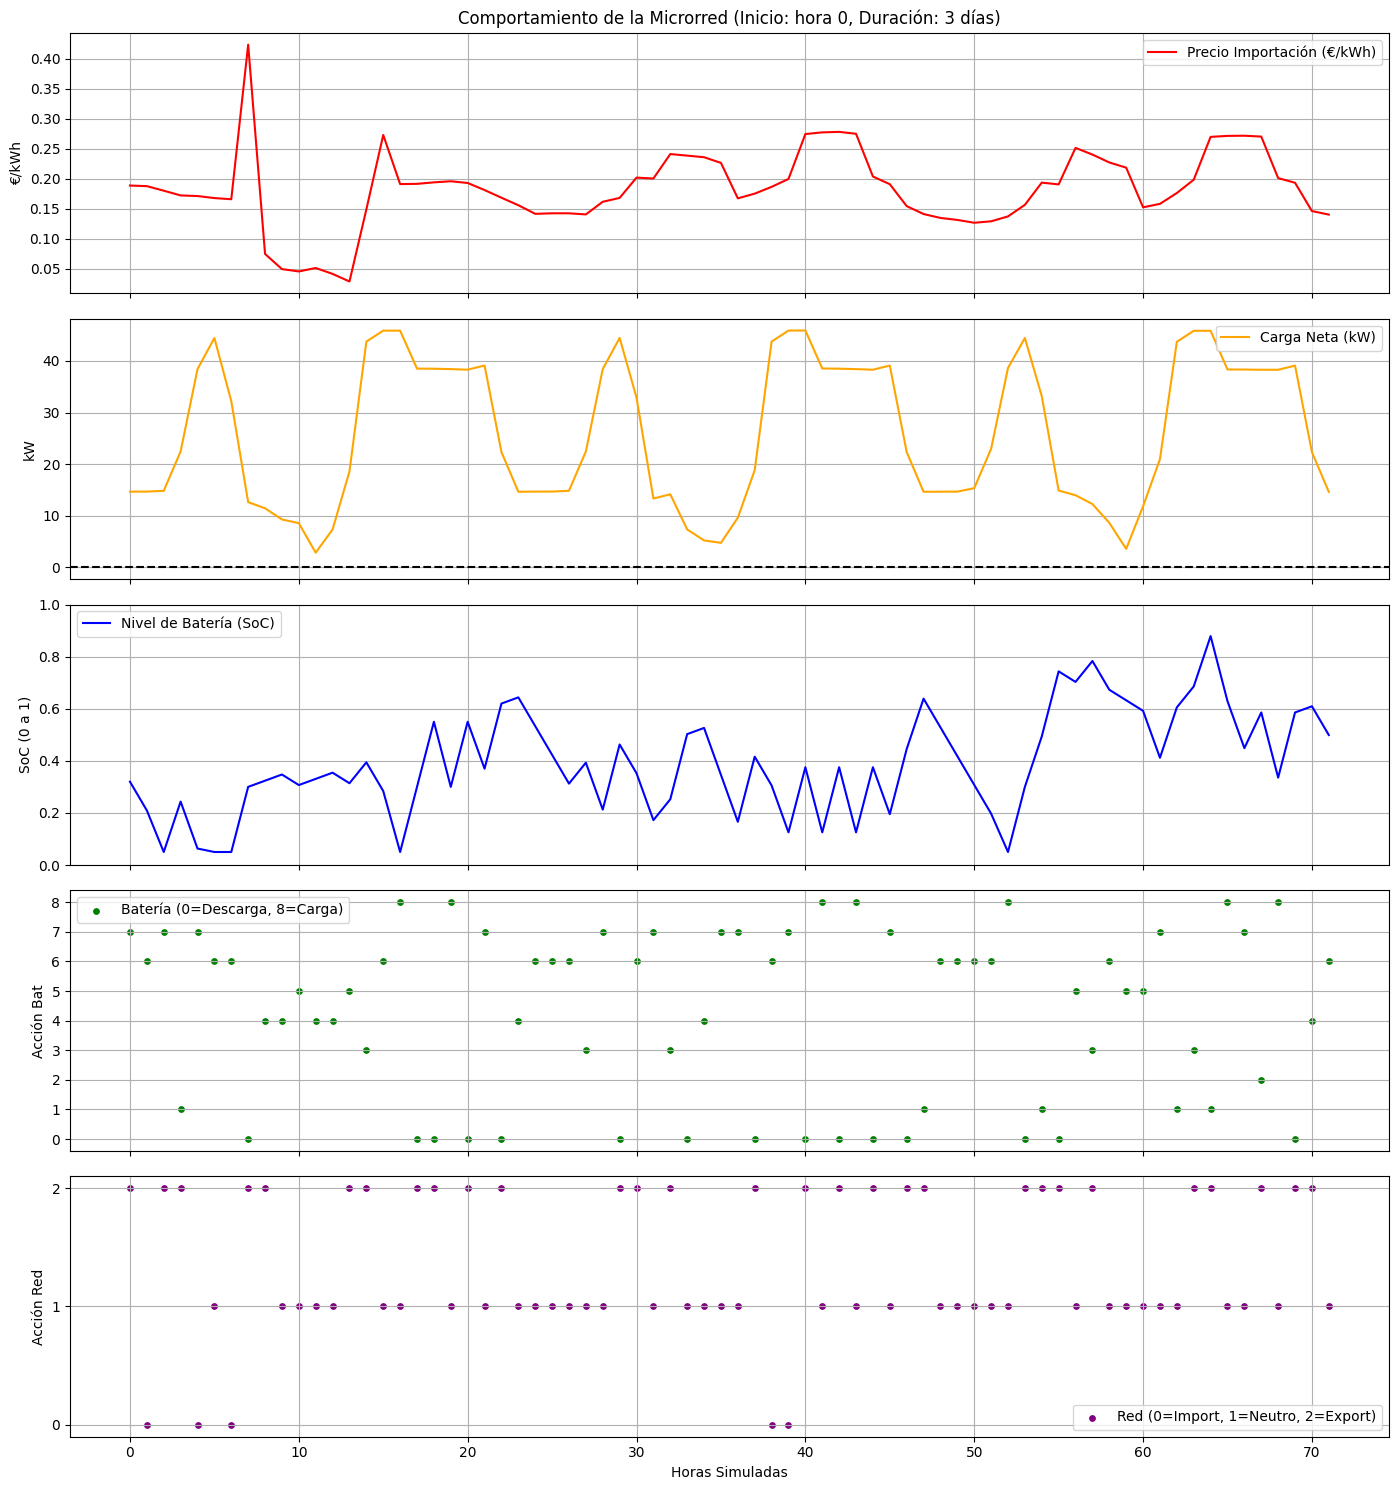

In [18]:
# ==============================================================================
# 2. CARGA DEL MEJOR AGENTE Y VISUALIZACIÓN
# ==============================================================================

# 1. Cargar el cerebro (Q-Table) del disco duro
if os.path.exists(GLOBAL_BEST_PATH):
    with open(GLOBAL_BEST_PATH, 'rb') as f:
        Q_ganadora = pickle.load(f)
    print(f"¡Cerebro cargado con éxito! Estados aprendidos: {len(Q_ganadora)}")
else:
    print(f"Error: No se ha encontrado el archivo {GLOBAL_BEST_PATH}. ¡Entrena primero!")

# 2. Instanciar un entorno limpio para la evaluación
microrred_eval = Microgrid([('grid', grid), ('battery', battery), ('load', load), ('pv', pv)])
env_eval = CustomEnvTabular(
    pymgrid_network=microrred_eval, 
    horizon=min_len, 
    low_soc_penalty=50.0, 
    low_soc_threshold=0.20
)

# 3. LÁNZAR LAS VISUALIZACIONES
# Descomenta las que quieras ver

# Ver 3 días de comportamiento simulado:
visualizar_comportamiento(env_eval, Q_ganadora, dias=3, hora_inicio=0)

# Ver el mapa de calor de exploración (qué estados conoce):
# visualizar_exploracion(Q_ganadora)

# Ver el mapa de decisiones fijando un precio (ej: 2) y demanda (ej: 2):
# visualizar_politica(Q_ganadora, precio_fijo=2, carga_fija=2)

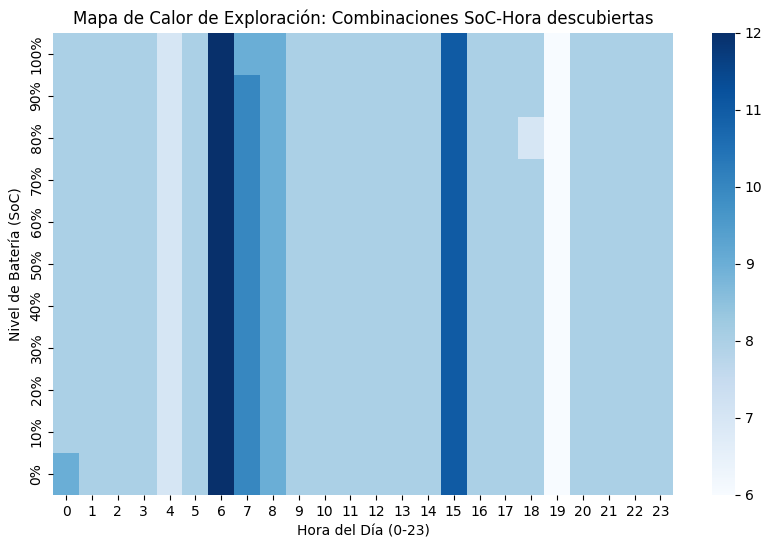

In [19]:
visualizar_exploracion(Q_ganadora)

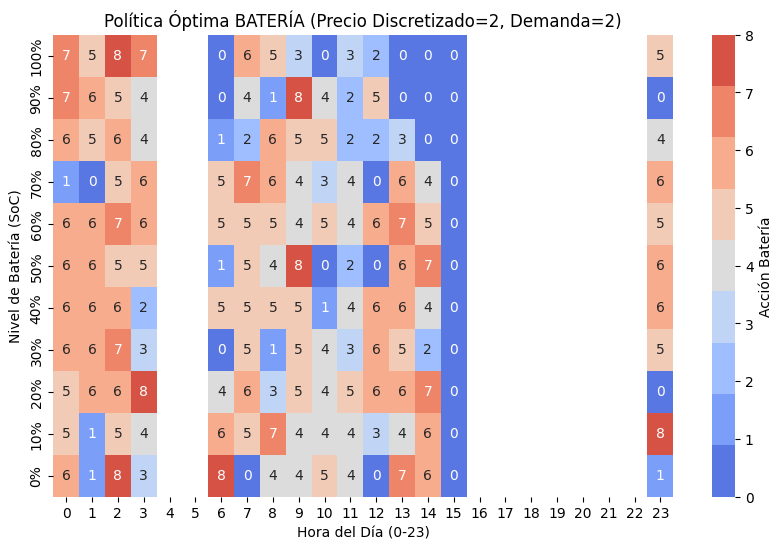

In [20]:
visualizar_politica(Q_ganadora, precio_fijo=2, carga_fija=2)

# Entrenamiento